TEMU BUSINESS STRATEGY ANALYSIS
How Temu Built a $70 Billion Business in 3 Years

Data Sources: Business of Apps, Backlinko, MobiLoud,
PDD Holdings Investor Disclosures
All figures are public estimates — Temu is privately held

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

In [3]:
folder=r'C:\Users\USER\Documents\New folder'

In [4]:
df_growth      = pd.read_csv(os.path.join(folder, 'temu_growth.csv'))
df_ad_spend    = pd.read_csv(os.path.join(folder, 'temu_ad_spend.csv'))
df_competitors = pd.read_csv(os.path.join(folder, 'competitors.csv'))

In [5]:
df_growth.head() 

,Quarter,MAU_Millions,Cumulative_Downloads_Millions,GMV_USD_Billion,Ad_Spend_USD_Billion,Avg_Order_Value_USD,New_Market_Event
0,Q4 2022,5.8,15,0.275,0.30,24.0,US Launch September 2022
1,Q1 2023,104.2,80,3.000,0.90,28.0,Super Bowl Ad Feb 2023
2,Q2 2023,70.5,150,5.000,0.85,31.0,Surpassed Shein US users
3,Q3 2023,82.4,250,8.000,0.80,35.0,EU expansion begins
4,Q4 2023,167.0,300,15.100,1.00,38.9,Peak US growth


In [6]:
df_ad_spend.head()

,Period,US_Ad_Spend_USD_Billion,EU_Ad_Spend_USD_Billion,Meta_Spend_USD_Billion,Google_Spend_USD_Billion,Total_USD_Billion,US_Strategy,EU_Strategy
0,2022 Full Year,0.3,0.0,0.2,0.1,0.3,Launch blitz,Not entered
1,2023 Full Year,2.5,0.5,2.0,0.8,3.0,Aggressive acquisition,Early entry
2,2024 Full Year,2.8,1.2,2.5,1.0,4.0,Sustain and convert,Accelerate
3,Q1 2025,0.2,0.8,0.5,0.0,1.0,Halted Google ads,40% MoM increase France
4,Q2 2025,0.1,1.1,0.4,0.0,1.2,Near full withdrawal,20% MoM increase UK


In [7]:
df_competitors.head()

,Company,Revenue_2023_USD_Billion,Revenue_2024_USD_Billion,MAU_2024_Millions,Avg_Order_Value_USD,Market,Loss_Per_Order_USD
0,Amazon,700.0,750.0,300,47.0,Global,Profitable
1,Shein,24.0,30.0,150,35.0,Global,Profitable
2,Temu,18.0,70.8,280,38.9,Global,-30.00
3,AliExpress,12.0,14.0,100,32.0,Global,-5.00
4,Wish,0.5,0.3,12,22.0,US declining,-15.00


had a pre clean on excel so we just going for eda and analysis here

 Revenue per active user

In [34]:
df_growth ['Revenue_Per_User_USD'] = (
    (df_growth['GMV_USD_Billion'] * 1_000_000_000) /
    (df_growth['MAU_Millions'] * 1_000_000)
).round(2)

In [9]:
df_growth['Revenue_Per_User_USD']

0      47.41
1      28.79
2      70.92
3      97.09
4      90.42
5      56.50
6      63.32
7      72.00
8     100.00
9      45.14
10     55.85
Name: Revenue_Per_User_USD, dtype: float64

Ad spend per active user

In [10]:
df_growth['Ad_Cost_Per_User_USD'] = (
    (df_growth['Ad_Spend_USD_Billion'] * 1_000_000_000) /
    (df_growth['MAU_Millions'] * 1_000_000)
).round(2)

In [11]:
df_growth['Ad_Cost_Per_User_USD']

0     51.72
1      8.64
2     12.06
3      9.71
4      5.99
5      6.00
6      5.16
7      4.00
8      4.29
9      0.68
10     1.35
Name: Ad_Cost_Per_User_USD, dtype: float64

Net value per user 

In [14]:
df_growth['Net_Value_Per_User_USD'] = (
df_growth['Revenue_Per_User_USD'] - df_growth['Ad_Cost_Per_User_USD']
).round(2)

 Positive = making money per user
 Negative = losing money per user

In [15]:
df_growth['Net_Value_Per_User_USD']

0     -4.31
1     20.15
2     58.86
3     87.38
4     84.43
5     50.50
6     58.16
7     68.00
8     95.71
9     44.46
10    54.50
Name: Net_Value_Per_User_USD, dtype: float64

 Quarter on quarter GMV growth rate

In [17]:
df_growth['GMV_Growth_Pct'] = (
    df_growth['GMV_USD_Billion'].pct_change() * 100
).round(2)


In [18]:
df_growth['GMV_Growth_Pct'] 

0        NaN
1     990.91
2      66.67
3      60.00
4      88.75
5     -25.17
6      19.47
7      33.33
8      55.56
9     -52.93
10     10.17
Name: GMV_Growth_Pct, dtype: float64

Temu loses roughly $30 per order, avg order value is $38.90
 Loss ratio = 30 / 38.90 = 77% of revenue is lost to costs

In [20]:
df_growth['Estimated_Loss_USD_Billion'] = (
df_growth['GMV_USD_Billion'] * 0.77
).round(3)

In [21]:
df_growth['Estimated_Loss_USD_Billion']

0      0.212
1      2.310
2      3.850
3      6.160
4     11.627
5      8.701
6     10.395
7     13.860
8     21.560
9     10.149
10    11.180
Name: Estimated_Loss_USD_Billion, dtype: float64

EU spend as percentage of US spend
When this crosses 100% it means EU spend exceeded US spend
That is the exact moment the pivot happened

In [23]:
df_ad_spend['EU_as_Pct_of_US'] = (
    (df_ad_spend['EU_Ad_Spend_USD_Billion'] /
     df_ad_spend['US_Ad_Spend_USD_Billion']) * 100
).round(1)

In [24]:
df_ad_spend['EU_as_Pct_of_US']

0       0.0
1      20.0
2      42.9
3     400.0
4    1100.0
Name: EU_as_Pct_of_US, dtype: float64

Annual revenue per MAU
Who makes the most money per active user?

In [30]:
df_competitors['Annual_Revenue_Per_User_USD'] = (
    (df_competitors['Revenue_2024_USD_Billion'] * 1_000_000_000) /
    (df_competitors['MAU_2024_Millions'] * 1_000_000)
).round(2)

In [28]:
['Annual_Revenue_Per_User_USD']

['Annual_Revenue_Per_User_USD']

In [ ]:
Revenue growth from 2023 to 2024

In [27]:
df_competitors['Revenue_Growth_Pct'] = (
    ((df_competitors['Revenue_2024_USD_Billion'] -
      df_competitors['Revenue_2023_USD_Billion']) /
     df_competitors['Revenue_2023_USD_Billion']) * 100
).round(1)

new column
Quarter', 'GMV_USD_Billion', 'Revenue_Per_User_USD',
              'Ad_Cost_Per_User_USD', 'Net_Value_Per_User_USD',
              'GMV_Growth_Pct']]

In [36]:
df_growth

,Quarter,MAU_Millions,Cumulative_Downloads_Millions,GMV_USD_Billion,Ad_Spend_USD_Billion,Avg_Order_Value_USD,New_Market_Event,Revenue_Per_User_USD,Ad_Cost_Per_User_USD,Net_Value_Per_User_USD,GMV_Growth_Pct,Estimated_Loss_USD_Billion
0,Q4 2022,5.8,15,0.275,0.30,24.0,US Launch September 2022,47.41,51.72,-4.31,NaN,0.212
1,Q1 2023,104.2,80,3.000,0.90,28.0,Super Bowl Ad Feb 2023,28.79,8.64,20.15,990.91,2.310
2,Q2 2023,70.5,150,5.000,0.85,31.0,Surpassed Shein US users,70.92,12.06,58.86,66.67,3.850
3,Q3 2023,82.4,250,8.000,0.80,35.0,EU expansion begins,97.09,9.71,87.38,60.00,6.160
4,Q4 2023,167.0,300,15.100,1.00,38.9,Peak US growth,90.42,5.99,84.43,88.75,11.627
5,Q1 2024,200.0,380,11.300,1.20,40.0,Super Bowl 2024 three ads,56.50,6.00,50.50,-25.17,8.701
6,Q2 2024,213.2,431,13.500,1.10,42.0,EU acceleration,63.32,5.16,58.16,19.47,10.395
7,Q3 2024,250.0,460,18.000,1.00,44.0,US saturation begins,72.00,4.00,68.00,33.33,13.860
8,Q4 2024,280.0,484,28.000,1.20,46.0,Holiday peak,100.00,4.29,95.71,55.56,21.560
9,Q1 2025,292.0,520,13.180,0.20,38.0,US tariff shock - ads halted,45.14,0.68,44.46,-52.93,10.149


In [38]:
df_competitors

,Company,Revenue_2023_USD_Billion,Revenue_2024_USD_Billion,MAU_2024_Millions,Avg_Order_Value_USD,Market,Loss_Per_Order_USD,Annual_Revenue_Per_User_USD,Revenue_Growth_Pct
0,Amazon,700.0,750.0,300,47.0,Global,Profitable,2500.00,7.1
1,Shein,24.0,30.0,150,35.0,Global,Profitable,200.00,25.0
2,Temu,18.0,70.8,280,38.9,Global,-30.00,252.86,293.3
3,AliExpress,12.0,14.0,100,32.0,Global,-5.00,140.00,16.7
4,Wish,0.5,0.3,12,22.0,US declining,-15.00,25.00,-40.0


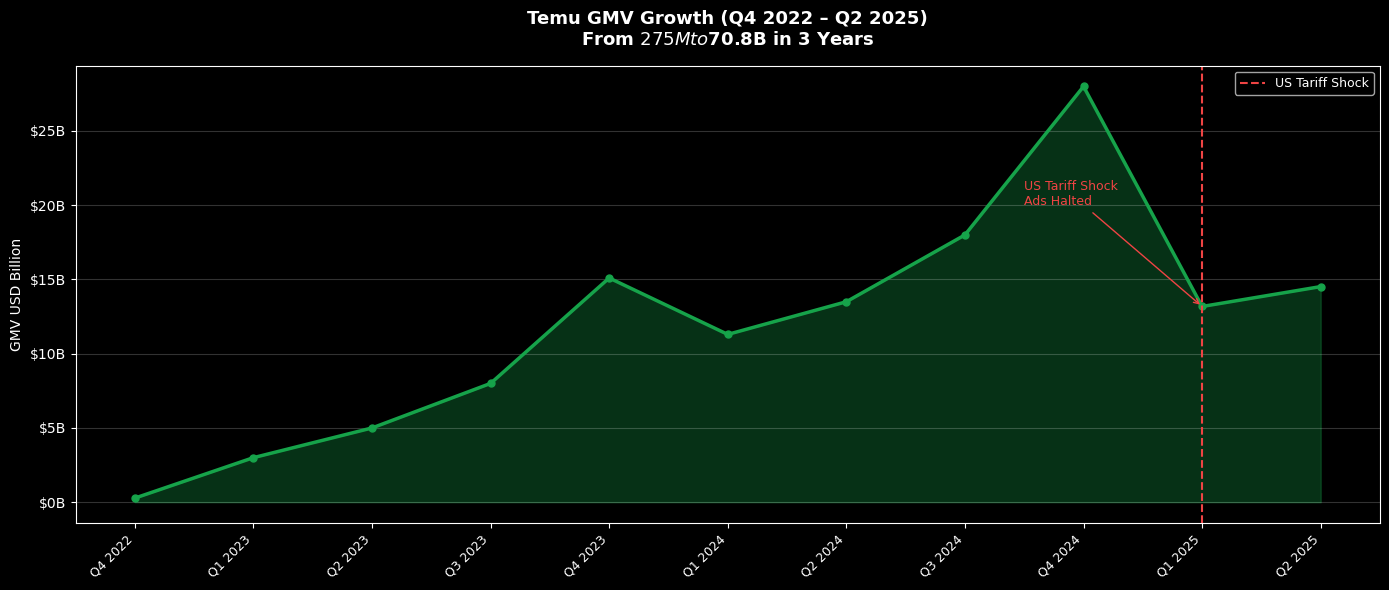

Chart 1 saved


In [44]:
plt.style.use('dark_background')

GREEN  = '#16a34a'
RED    = '#ef4444'
YELLOW = '#fbbf24'
BLUE   = '#3b82f6'
GREY   = '#64748b'

quarters = df_growth['Quarter']
x = range(len(quarters))
# CHART 1: GMV GROWTH 
# The explosion and the tariff shock dip in one chart
fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(x, df_growth['GMV_USD_Billion'], alpha=0.3, color=GREEN)
ax.plot(x, df_growth['GMV_USD_Billion'],
        color=GREEN, linewidth=2.5, marker='o', markersize=5)

# Find Q1 2025 row and mark the tariff shock on the chart
tariff_idx = df_growth[df_growth['Quarter'].str.contains('Q1 2025')].index
if len(tariff_idx) > 0:
    idx = tariff_idx[0]
    ax.axvline(x=idx, color=RED, linestyle='--',
               linewidth=1.5, label='US Tariff Shock')
    ax.annotate(
        'US Tariff Shock\nAds Halted',
        xy=(idx, df_growth.loc[idx, 'GMV_USD_Billion']),
        xytext=(idx - 1.5, 20),
        color=RED, fontsize=9,
        arrowprops=dict(arrowstyle='->', color=RED)
    )

ax.set_xticks(x)
ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=9)
ax.set_title(
    'Temu GMV Growth (Q4 2022 – Q2 2025)\nFrom $275M to $70.8B in 3 Years',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_ylabel('GMV USD Billion', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fB'))
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(folder, 'chart1_gmv_growth.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print("Chart 1 saved")


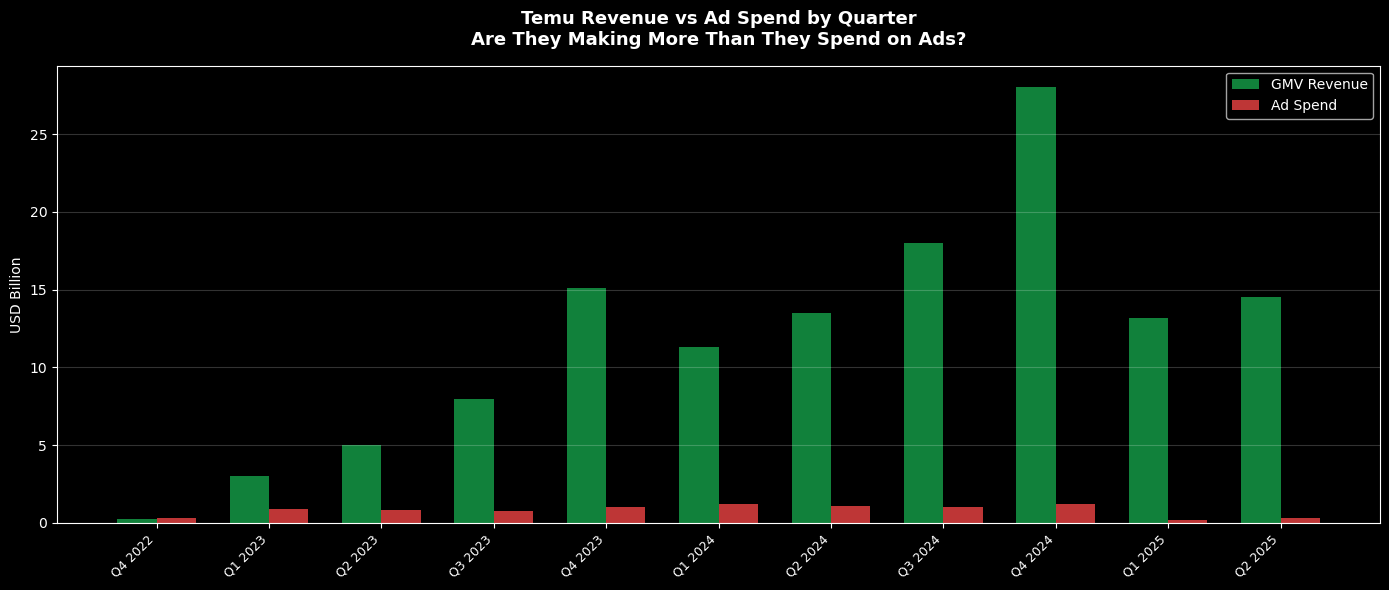

Chart 2 saved


In [46]:
#  CHART 2: REVENUE vs AD SPEND
# The KEY business question chart
# Green bars = what they made, Red bars = what they spent on ads
fig, ax = plt.subplots(figsize=(14, 6))

bar_width = 0.35
ax.bar([i - bar_width/2 for i in x],
       df_growth['GMV_USD_Billion'],
       width=bar_width, color=GREEN, alpha=0.8, label='GMV Revenue')
ax.bar([i + bar_width/2 for i in x],
       df_growth['Ad_Spend_USD_Billion'],
       width=bar_width, color=RED, alpha=0.8, label='Ad Spend')

ax.set_xticks(x)
ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('USD Billion', fontsize=10)
ax.set_title(
    'Temu Revenue vs Ad Spend by Quarter\nAre They Making More Than They Spend on Ads?',
    fontsize=13, fontweight='bold', pad=15
)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(folder, 'chart2_revenue_vs_adspend.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print("Chart 2 saved")

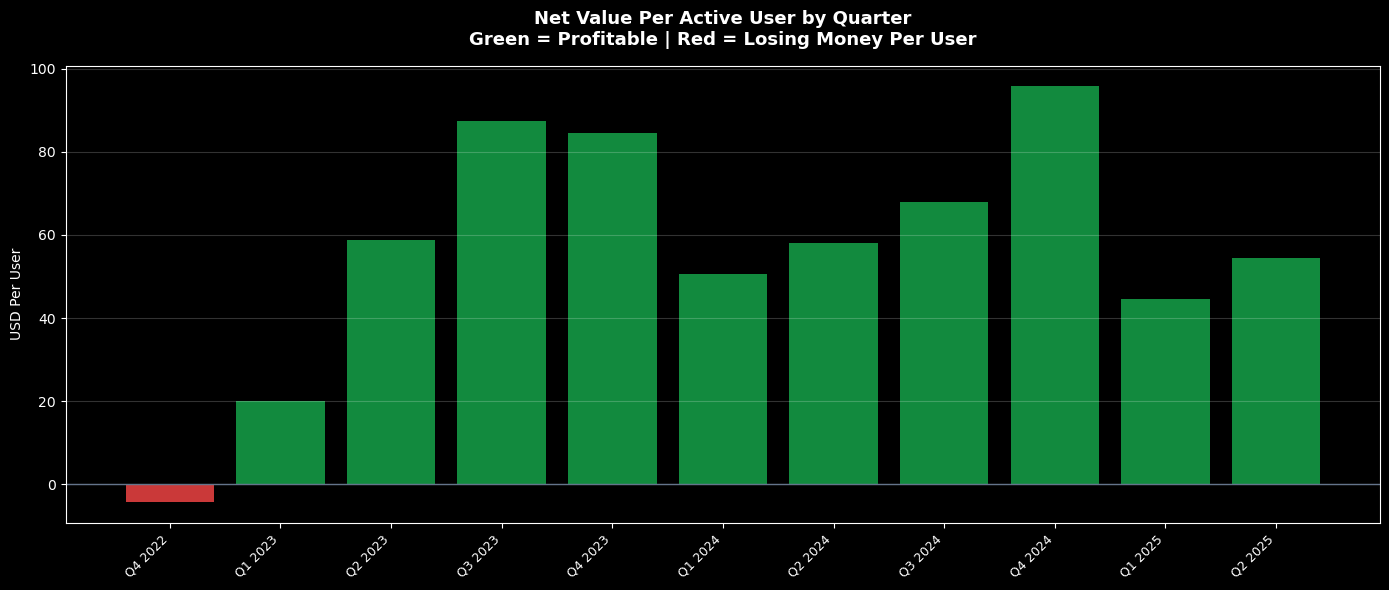

Chart 3 saved


In [49]:
# ── CHART 3: NET VALUE PER USER ──────────────────────────────
# Green bar = profitable per user that quarter
# Red bar = losing money per user that quarter
fig, ax = plt.subplots(figsize=(14, 6))

bar_colors = [GREEN if v >= 0 else RED
              for v in df_growth['Net_Value_Per_User_USD']]
ax.bar(x, df_growth['Net_Value_Per_User_USD'],
       color=bar_colors, alpha=0.85)
ax.axhline(y=0, color=GREY, linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=9)
ax.set_title(
    'Net Value Per Active User by Quarter\nGreen = Profitable | Red = Losing Money Per User',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_ylabel('USD Per User', fontsize=10)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(folder, 'chart3_net_value_per_user.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print("Chart 3 saved")

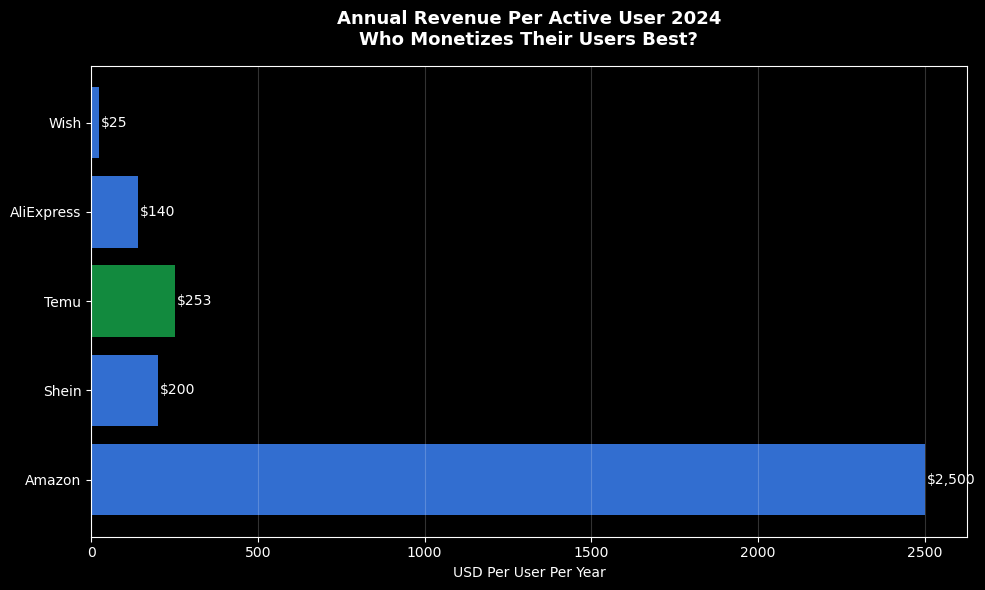

Chart 4 saved


In [51]:

# ── CHART 4: COMPETITIVE REVENUE PER USER ───────────────────
# Who monetizes their users best?
# FINDING: Amazon makes far more per user than Temu
fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = [GREEN if c == 'Temu' else BLUE
              for c in df_competitors['Company']]
bars = ax.barh(df_competitors['Company'],
               df_competitors['Annual_Revenue_Per_User_USD'],
               color=bar_colors, alpha=0.85)

# Add value labels to the end of each bar
for bar, val in zip(bars, df_competitors['Annual_Revenue_Per_User_USD']):
    ax.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height() / 2,
        f'${val:,.0f}',
        va='center', fontsize=10, color='white'
    )

ax.set_title(
    'Annual Revenue Per Active User 2024\nWho Monetizes Their Users Best?',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('USD Per User Per Year', fontsize=10)
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(folder, 'chart4_revenue_per_user_comparison.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print("Chart 4 saved")


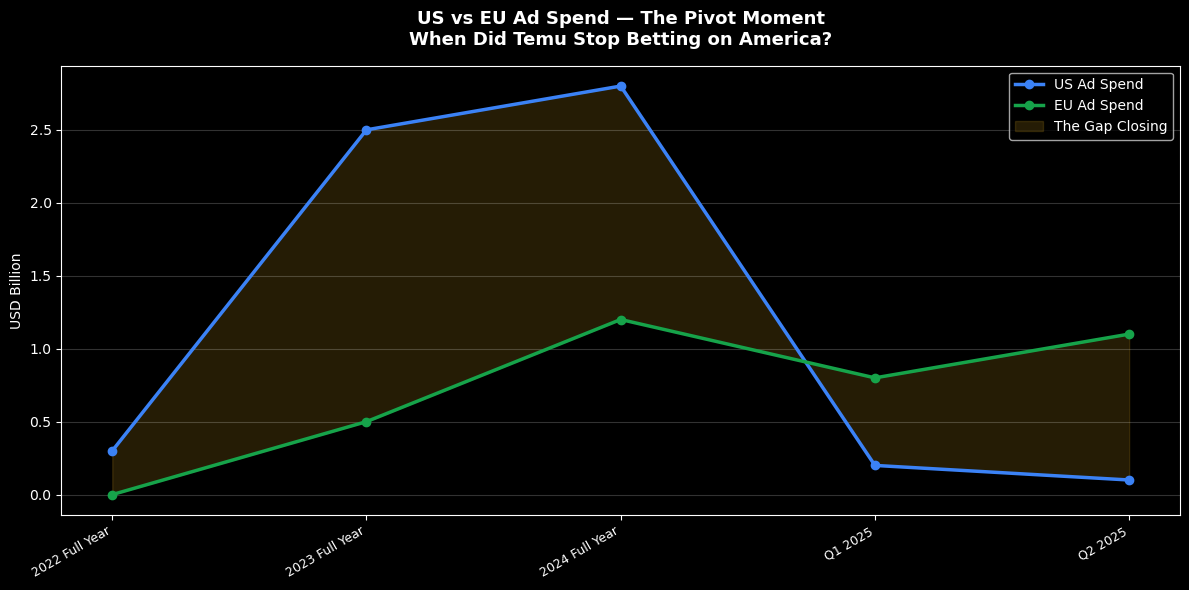

Chart 5 saved


In [52]:

# ── CHART 5: EU vs US AD SPEND PIVOT ────────────────────────
# Shows exactly when Temu stopped betting on America
fig, ax = plt.subplots(figsize=(12, 6))

periods = df_ad_spend['Period']
xp = range(len(periods))

ax.plot(xp, df_ad_spend['US_Ad_Spend_USD_Billion'],
        color=BLUE, linewidth=2.5, marker='o',
        markersize=6, label='US Ad Spend')
ax.plot(xp, df_ad_spend['EU_Ad_Spend_USD_Billion'],
        color=GREEN, linewidth=2.5, marker='o',
        markersize=6, label='EU Ad Spend')

ax.fill_between(xp,
                df_ad_spend['US_Ad_Spend_USD_Billion'],
                df_ad_spend['EU_Ad_Spend_USD_Billion'],
                alpha=0.15, color=YELLOW,
                label='The Gap Closing')

ax.set_xticks(xp)
ax.set_xticklabels(periods, rotation=30, ha='right', fontsize=9)
ax.set_title(
    'US vs EU Ad Spend — The Pivot Moment\nWhen Did Temu Stop Betting on America?',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_ylabel('USD Billion', fontsize=10)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(folder, 'chart5_us_vs_eu_pivot.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print("Chart 5 saved")



In [56]:

# SECTION 4 — SAVE CLEAN FILES FOR SQL IMPORT

# index=False means do NOT save row numbers as a column
# encoding utf-8-sig handles special characters in Excel

df_growth.to_csv(
    os.path.join(folder, 'temu_growth_clean.csv'),
    index=False, encoding='utf-8-sig'
)
df_ad_spend.to_csv(
    os.path.join(folder, 'temu_ad_spend_clean.csv'),
    index=False, encoding='utf-8-sig'
)
df_competitors.to_csv(
    os.path.join(folder, 'competitors_clean.csv'),
    index=False, encoding='utf-8-sig'
)

print("\n✓ All 3 clean CSV files saved and ready for SQL import")
print(f"  Growth:      {df_growth.shape[0]} rows x {df_growth.shape[1]} columns")
print(f"  Ad Spend:    {df_ad_spend.shape[0]} rows x {df_ad_spend.shape[1]} columns")
print(f"  Competitors: {df_competitors.shape[0]} rows x {df_competitors.shape[1]} columns")
print("\n✓ All 5 charts saved as PNG files")
print("\nNext step: Import the 3 _clean.csv files into MySQL Workbench")


✓ All 3 clean CSV files saved and ready for SQL import
  Growth:      11 rows x 12 columns
  Ad Spend:    5 rows x 9 columns
  Competitors: 5 rows x 9 columns

✓ All 5 charts saved as PNG files

Next step: Import the 3 _clean.csv files into MySQL Workbench
